In [1]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'

from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FuncFormatter
import xarray as xr
import numpy as np
from scipy.ndimage import gaussian_filter

print('done')


done


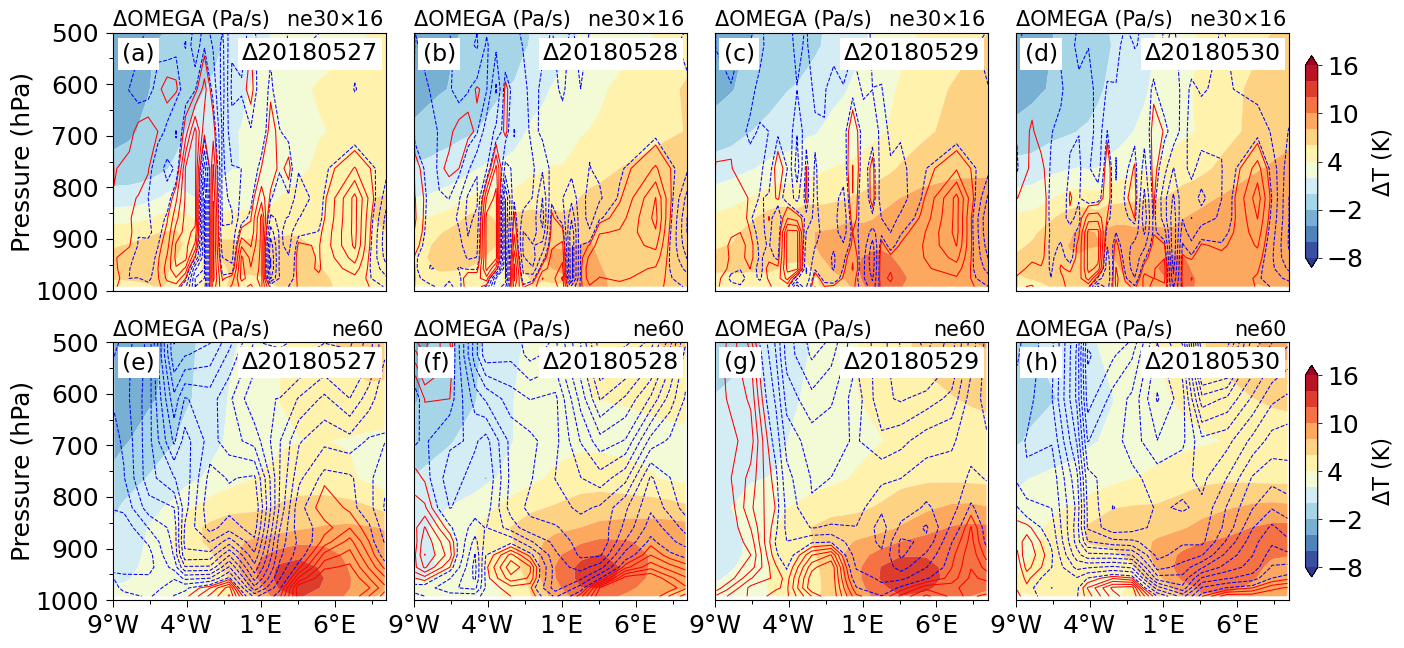

In [ ]:
date_list = ['2018-05-27', '2018-05-28', '2018-05-29', '2018-05-30']
lat0, dlat = 51, 0.25

case_specs = [
    {
        "base_dir": "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist",
        "file_prefix": "MUSICA_production3.2_BB.cam.h3",
        "lon_min": -9,
        "lon_max": 9,
        "n": 50,
        "label": r"ne30$\times$16",
        "letters": ['(a)', '(b)', '(c)', '(d)'],
        "omega_clip": (-60, 40),
        "neg_levels": np.arange(-60, 0, 14),
        "pos_levels": np.arange(0, 40, 12),
        "row": 0,
        "contour_linewidth": 0.75,
    },
    {
        "base_dir": "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist",
        "file_prefix": "MUSICAv0_ne60_production.cam.h3",
        "lon_min": -9,
        "lon_max": 9.5,
        "n": 2,
        "label": r"ne60",
        "letters": ['(e)', '(f)', '(g)', '(h)'],
        "omega_clip": (-41, 5),
        "neg_levels": np.arange(-41, 0, 2),
        "pos_levels": np.arange(0, 5, 1),
        "row": 1,
        "contour_linewidth": 0.75,
    },
]


def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    elif x > 0:
        return f"{x:.0f}°E"
    else:
        return f"{abs(x):.0f}°W"


def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    elif y > 0:
        return f"{y:.0f}°N"
    else:
        return f"{abs(y):.0f}°S"


def prepare_case(spec):
    base_file = f"{spec['base_dir']}/{spec['file_prefix']}.2018-05-20-00000.nc"
    ds_base = xr.open_dataset(base_file)

    lat = ds_base['lat'].values
    lon = ds_base['lon'].values
    lev = ds_base['lev'].values
    idx_lat = np.where(np.abs(lat - lat0) <= dlat)[0]
    lon_ = lon.copy()
    lon_[lon_ > 180] -= 360
    idx_lon = np.where((lon_[idx_lat] >= spec['lon_min']) & (lon_[idx_lat] <= spec['lon_max']))[0]
    idx_sel = idx_lat[idx_lon]
    lon_sel = lon_[idx_sel]
    sorter = np.argsort(lon_sel)
    lon_sel = lon_sel[sorter]
    return ds_base, lev, idx_sel, sorter, lon_sel


VERT_TICK_SIZE = 18
VERT_X_TICK_LABEL_SIZE = 18
VERT_Y_TICK_LABEL_SIZE = VERT_TICK_SIZE
VERT_X_MAJOR_TICK_LENGTH = 5
VERT_X_MINOR_TICK_LENGTH = 3
VERT_Y_MAJOR_TICK_LENGTH = 5
VERT_Y_MINOR_TICK_LENGTH = 3
VERT_X_MAJOR_TICK_WIDTH = 0.7
VERT_X_MINOR_TICK_WIDTH = 0.7
VERT_Y_MAJOR_TICK_WIDTH = 0.8
VERT_Y_MINOR_TICK_WIDTH = 0.7
VERT_X_TICK_PAD = 5
VERT_Y_TICK_PAD = 5
VERT_Y_TICK_INTERVAL = 100


def style_vertical_axis(ax, row, col, lon_min, lon_max):
    ax.invert_yaxis()
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(1000, 500)
    ax.set_yticks(np.arange(500, 1001, VERT_Y_TICK_INTERVAL))

    xticks = np.array([-9, -4, 1, 6])
    xticks = xticks[(xticks >= lon_min) & (xticks <= lon_max)]
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(
        axis='x', which='major', labelsize=VERT_X_TICK_LABEL_SIZE,
        pad=VERT_X_TICK_PAD, length=VERT_X_MAJOR_TICK_LENGTH,
        width=VERT_X_MAJOR_TICK_WIDTH, bottom=True, top=False, labelbottom=True,
    )
    ax.tick_params(
        axis='x', which='minor', length=VERT_X_MINOR_TICK_LENGTH,
        width=VERT_X_MINOR_TICK_WIDTH, bottom=True, top=False, labelbottom=False,
    )
    if row == 0:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    if col == 0:
        ax.set_ylabel('Pressure (hPa)', fontsize=18, labelpad=1)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(
            axis='y', which='major', labelsize=VERT_Y_TICK_LABEL_SIZE,
            pad=VERT_Y_TICK_PAD, length=VERT_Y_MAJOR_TICK_LENGTH,
            width=VERT_Y_MAJOR_TICK_WIDTH,
        )
        ax.tick_params(
            axis='y', which='minor', length=VERT_Y_MINOR_TICK_LENGTH,
            width=VERT_Y_MINOR_TICK_WIDTH,
        )
    else:
        ax.set_ylabel('', fontsize=11, labelpad=12)
        ax.yaxis.set_tick_params(labelleft=False, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(
            axis='y', which='major', labelsize=VERT_Y_TICK_LABEL_SIZE,
            pad=VERT_Y_TICK_PAD, length=VERT_Y_MAJOR_TICK_LENGTH,
            width=VERT_Y_MAJOR_TICK_WIDTH, labelleft=False, labelright=False,
            left=False, right=False,
        )
        ax.tick_params(
            axis='y', which='minor', length=VERT_Y_MINOR_TICK_LENGTH,
            width=VERT_Y_MINOR_TICK_WIDTH, labelleft=False, labelright=False,
            left=False, right=False,
        )


fig, axes = plt.subplots(2, 4, figsize=(13.6, 6.6))
last_cf_by_row = [None, None]
temp_levels = np.arange(-8, 17, 2)

for spec in case_specs:
    ds_base, lev, idx_sel, sorter, lon_sel = prepare_case(spec)

    for i, date_str in enumerate(date_list):
        file_nc = f"{spec['base_dir']}/{spec['file_prefix']}.{date_str}-00000.nc"
        ds = xr.open_dataset(file_nc)

        T_diff = ds['T'][0, :, :].values - ds_base['T'][0, :, :].values
        OMEGA_diff = (ds['OMEGA'][0, :, :].values - ds_base['OMEGA'][0, :, :].values) * 100
        T_sel = T_diff[:, idx_sel][:, sorter]
        OMEGA_sel = OMEGA_diff[:, idx_sel][:, sorter]

        N = len(lon_sel)
        idx_sparse = np.concatenate(([0], np.arange(1, N - 1, spec['n']), [N - 1]))
        lon_sel_sparse = lon_sel[idx_sparse]
        T_sel_sparse = T_sel[:, idx_sparse]
        OMEGA_sel_sparse = OMEGA_sel[:, idx_sparse]
        OMEGA_sel_sparse = np.clip(OMEGA_sel_sparse, *spec['omega_clip'])
        Lon, Lev = np.meshgrid(lon_sel_sparse, lev)
        T_smooth = gaussian_filter(T_sel_sparse, sigma=0.6)

        ax = axes[spec['row'], i]
        cf = ax.contourf(
            Lon, Lev, T_smooth,
            levels=temp_levels,
            cmap='RdYlBu_r', extend='both', antialiased=True
        )
        last_cf_by_row[spec['row']] = cf

        ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=spec['neg_levels'],
                   colors='b', linestyles='dashed', linewidths=spec['contour_linewidth'])
        ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=spec['pos_levels'],
                   colors='r', linestyles='solid', linewidths=spec['contour_linewidth'])

        style_vertical_axis(ax, spec['row'], i, spec['lon_min'], spec['lon_max'])

        ax.text(0.0, 1.01, 'ΔOMEGA (Pa/s)', fontsize=15,
                ha='left', va='bottom', transform=ax.transAxes)
        ax.text(0.99, 1.01, spec['label'], fontsize=15,
                ha='right', va='bottom', transform=ax.transAxes)
        ax.text(0.033, 0.962 if spec['row'] == 0 else 0.965, spec['letters'][i],
                fontsize=17, va='top', ha='left', transform=ax.transAxes,
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='square,pad=0.18'))
        day = 27 + i
        ax.text(0.97, 0.962 if spec['row'] == 0 else 0.965, f"Δ201805{day:02d}",
                fontsize=17, va='top', ha='right', transform=ax.transAxes,
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='square,pad=0.18'))

fig.subplots_adjust(left=0.055, right=0.92, bottom=0.07, top=0.93, wspace=0.10, hspace=0.2)

cbar_width = 0.009
cbar_pad = 0.012
cbar_height_ratio = 0.82

for row, cf in enumerate(last_cf_by_row):
    right_ax_pos = axes[row, -1].get_position()
    cbar_height = right_ax_pos.height * cbar_height_ratio
    cbar_y0 = right_ax_pos.y0 + (right_ax_pos.height - cbar_height) / 2
    cax = fig.add_axes([
        right_ax_pos.x1 + cbar_pad,
        cbar_y0,
        cbar_width,
        cbar_height,
    ])
    cbar = fig.colorbar(
        cf,
        cax=cax,
        orientation='vertical',
        ticks=np.arange(-8, 18, 6),
        extend='both'
    )
    cbar.set_label('ΔT (K)', fontsize=16, rotation=90, labelpad=6)
    cbar.ax.tick_params(labelsize=18, length=3, width=0.6)




In [3]:
figure_data_dir = '/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data'
os.makedirs(figure_data_dir, exist_ok=True)
figure_s8_path = os.path.join(figure_data_dir, 'FigureS8.nc')

figure_s8_cases = []
max_lon_points = 0
n_levels = None

for spec in case_specs:
    ds_base, lev, idx_sel, sorter, lon_sel = prepare_case(spec)
    case_data = {
        'case': spec['label'],
        'lon_min': spec['lon_min'],
        'lon_max': spec['lon_max'],
        'lon': None,
        'temperature_difference': [],
        'omega_difference': [],
    }

    for date_str in date_list:
        file_nc = f"{spec['base_dir']}/{spec['file_prefix']}.{date_str}-00000.nc"
        ds = xr.open_dataset(file_nc)

        T_diff = ds['T'][0, :, :].values - ds_base['T'][0, :, :].values
        OMEGA_diff = (ds['OMEGA'][0, :, :].values - ds_base['OMEGA'][0, :, :].values) * 100
        T_sel = T_diff[:, idx_sel][:, sorter]
        OMEGA_sel = OMEGA_diff[:, idx_sel][:, sorter]

        N = len(lon_sel)
        idx_sparse = np.concatenate(([0], np.arange(1, N - 1, spec['n']), [N - 1]))
        lon_sel_sparse = lon_sel[idx_sparse]
        T_sel_sparse = T_sel[:, idx_sparse]
        OMEGA_sel_sparse = OMEGA_sel[:, idx_sparse]
        OMEGA_sel_sparse = np.clip(OMEGA_sel_sparse, *spec['omega_clip'])
        T_smooth = gaussian_filter(T_sel_sparse, sigma=0.6)

        case_data['lon'] = lon_sel_sparse
        case_data['temperature_difference'].append(T_smooth)
        case_data['omega_difference'].append(OMEGA_sel_sparse)

    case_data['temperature_difference'] = np.stack(case_data['temperature_difference'])
    case_data['omega_difference'] = np.stack(case_data['omega_difference'])
    figure_s8_cases.append(case_data)
    max_lon_points = max(max_lon_points, case_data['lon'].size)
    n_levels = len(lev)

case_names = [case['case'] for case in figure_s8_cases]
lon_values = np.full((len(figure_s8_cases), max_lon_points), np.nan)
temperature_difference = np.full((len(figure_s8_cases), len(date_list), n_levels, max_lon_points), np.nan)
omega_difference = np.full_like(temperature_difference, np.nan)
lon_min_values = np.full(len(figure_s8_cases), np.nan)
lon_max_values = np.full(len(figure_s8_cases), np.nan)

for case_idx, case in enumerate(figure_s8_cases):
    n_lon = case['lon'].size
    lon_values[case_idx, :n_lon] = case['lon']
    temperature_difference[case_idx, :, :, :n_lon] = case['temperature_difference']
    omega_difference[case_idx, :, :, :n_lon] = case['omega_difference']
    lon_min_values[case_idx] = case['lon_min']
    lon_max_values[case_idx] = case['lon_max']

FigureS8 = xr.Dataset(
    data_vars={
        'lon': (('case', 'point'), lon_values),
        'temperature_difference': (('case', 'date', 'lev', 'point'), temperature_difference),
        'omega_difference': (('case', 'date', 'lev', 'point'), omega_difference),
        'lon_min': (('case',), lon_min_values),
        'lon_max': (('case',), lon_max_values),
    },
    coords={
        'case': case_names,
        'date': date_list,
        'lev': lev,
        'point': np.arange(max_lon_points),
    },
)
FigureS8['temperature_difference'].attrs.update({'long_name': 'Smoothed temperature difference', 'units': 'K'})
FigureS8['omega_difference'].attrs.update({'long_name': 'Omega difference', 'units': 'Pa/s'})
FigureS8['lon'].attrs.update({'long_name': 'Longitude', 'units': 'degrees_east'})
FigureS8['lev'].attrs.update({'long_name': 'Pressure level', 'units': 'hPa'})

FigureS8.to_netcdf(figure_s8_path)


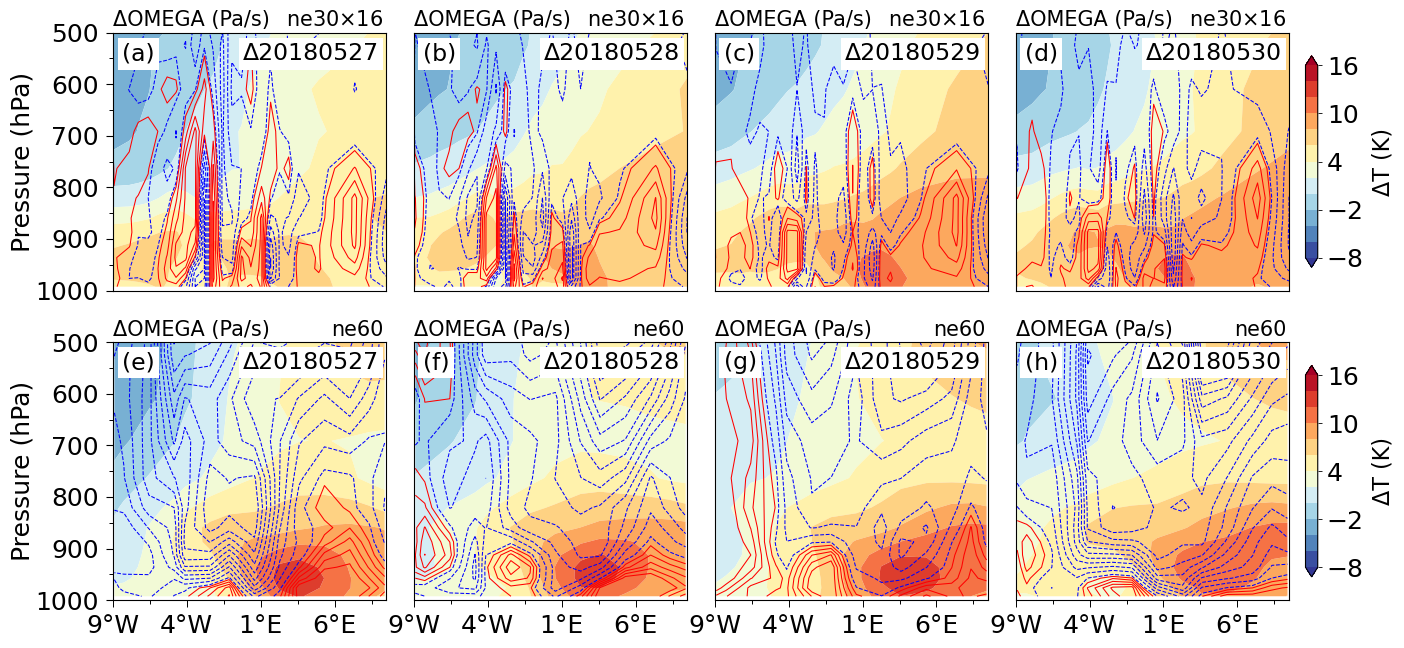

In [ ]:
figure_data_path = '/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS8.nc'
figure_ds = xr.open_dataset(figure_data_path)

saved_case_specs = [
    {
        "case": r"ne30$\times$16",
        "label": r"ne30$\times$16",
        "letters": ['(a)', '(b)', '(c)', '(d)'],
        "neg_levels": np.arange(-60, 0, 14),
        "pos_levels": np.arange(0, 40, 12),
        "row": 0,
        "contour_linewidth": 0.75,
    },
    {
        "case": r"ne60",
        "label": r"ne60",
        "letters": ['(e)', '(f)', '(g)', '(h)'],
        "neg_levels": np.arange(-41, 0, 2),
        "pos_levels": np.arange(0, 5, 1),
        "row": 1,
        "contour_linewidth": 0.75,
    },
]

VERT_TICK_SIZE = 18
VERT_X_TICK_LABEL_SIZE = 18
VERT_Y_TICK_LABEL_SIZE = VERT_TICK_SIZE
VERT_X_MAJOR_TICK_LENGTH = 5
VERT_X_MINOR_TICK_LENGTH = 3
VERT_Y_MAJOR_TICK_LENGTH = 5
VERT_Y_MINOR_TICK_LENGTH = 3
VERT_X_MAJOR_TICK_WIDTH = 0.7
VERT_X_MINOR_TICK_WIDTH = 0.7
VERT_Y_MAJOR_TICK_WIDTH = 0.8
VERT_Y_MINOR_TICK_WIDTH = 0.7
VERT_X_TICK_PAD = 5
VERT_Y_TICK_PAD = 5
VERT_Y_TICK_INTERVAL = 100


def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    if x > 0:
        return f"{x:.0f}°E"
    return f"{abs(x):.0f}°W"


def style_vertical_axis(ax, row, col, lon_min, lon_max):
    ax.invert_yaxis()
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(1000, 500)
    ax.set_yticks(np.arange(500, 1001, VERT_Y_TICK_INTERVAL))

    xticks = np.array([-9, -4, 1, 6])
    xticks = xticks[(xticks >= lon_min) & (xticks <= lon_max)]
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(
        axis='x', which='major', labelsize=VERT_X_TICK_LABEL_SIZE,
        pad=VERT_X_TICK_PAD, length=VERT_X_MAJOR_TICK_LENGTH,
        width=VERT_X_MAJOR_TICK_WIDTH, bottom=True, top=False, labelbottom=True,
    )
    ax.tick_params(
        axis='x', which='minor', length=VERT_X_MINOR_TICK_LENGTH,
        width=VERT_X_MINOR_TICK_WIDTH, bottom=True, top=False, labelbottom=False,
    )
    if row == 0:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    if col == 0:
        ax.set_ylabel('Pressure (hPa)', fontsize=18, labelpad=1)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(
            axis='y', which='major', labelsize=VERT_Y_TICK_LABEL_SIZE,
            pad=VERT_Y_TICK_PAD, length=VERT_Y_MAJOR_TICK_LENGTH,
            width=VERT_Y_MAJOR_TICK_WIDTH,
        )
        ax.tick_params(
            axis='y', which='minor', length=VERT_Y_MINOR_TICK_LENGTH,
            width=VERT_Y_MINOR_TICK_WIDTH,
        )
    else:
        ax.set_ylabel('', fontsize=11, labelpad=12)
        ax.yaxis.set_tick_params(labelleft=False, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(
            axis='y', which='major', labelsize=VERT_Y_TICK_LABEL_SIZE,
            pad=VERT_Y_TICK_PAD, length=VERT_Y_MAJOR_TICK_LENGTH,
            width=VERT_Y_MAJOR_TICK_WIDTH, labelleft=False, labelright=False,
            left=False, right=False,
        )
        ax.tick_params(
            axis='y', which='minor', length=VERT_Y_MINOR_TICK_LENGTH,
            width=VERT_Y_MINOR_TICK_WIDTH, labelleft=False, labelright=False,
            left=False, right=False,
        )


fig, axes = plt.subplots(2, 4, figsize=(13.6, 6.6))
last_cf_by_row = [None, None]
temp_levels = np.arange(-8, 17, 2)

for spec in saved_case_specs:
    case_ds = figure_ds.sel(case=spec['case'])
    lon_min = float(case_ds['lon_min'].values)
    lon_max = float(case_ds['lon_max'].values)

    for i, date_str in enumerate(figure_ds['date'].values.astype(str)):
        ax = axes[spec['row'], i]
        lon_sel_sparse = case_ds['lon'].values
        valid_lon = np.isfinite(lon_sel_sparse)
        lon_sel_sparse = lon_sel_sparse[valid_lon]
        lev = figure_ds['lev'].values
        T_smooth = case_ds['temperature_difference'].sel(date=date_str).values[:, valid_lon]
        OMEGA_sel_sparse = case_ds['omega_difference'].sel(date=date_str).values[:, valid_lon]
        Lon, Lev = np.meshgrid(lon_sel_sparse, lev)

        cf = ax.contourf(
            Lon, Lev, T_smooth,
            levels=temp_levels,
            cmap='RdYlBu_r', extend='both', antialiased=True
        )
        last_cf_by_row[spec['row']] = cf

        ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=spec['neg_levels'],
                   colors='b', linestyles='dashed', linewidths=spec['contour_linewidth'])
        ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=spec['pos_levels'],
                   colors='r', linestyles='solid', linewidths=spec['contour_linewidth'])

        style_vertical_axis(ax, spec['row'], i, lon_min, lon_max)

        ax.text(0.0, 1.01, 'ΔOMEGA (Pa/s)', fontsize=15,
                ha='left', va='bottom', transform=ax.transAxes)
        ax.text(0.99, 1.01, spec['label'], fontsize=15,
                ha='right', va='bottom', transform=ax.transAxes)
        ax.text(0.033, 0.962 if spec['row'] == 0 else 0.965, spec['letters'][i],
                fontsize=17, va='top', ha='left', transform=ax.transAxes,
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='square,pad=0.18'))
        day = 27 + i
        ax.text(0.974, 0.962 if spec['row'] == 0 else 0.965, f"Δ201805{day:02d}",
                fontsize=17, va='top', ha='right', transform=ax.transAxes,
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='square,pad=0.18'))

fig.subplots_adjust(left=0.055, right=0.92, bottom=0.07, top=0.93, wspace=0.10, hspace=0.2)

cbar_width = 0.009
cbar_pad = 0.012
cbar_height_ratio = 0.82

for row, cf in enumerate(last_cf_by_row):
    right_ax_pos = axes[row, -1].get_position()
    cbar_height = right_ax_pos.height * cbar_height_ratio
    cbar_y0 = right_ax_pos.y0 + (right_ax_pos.height - cbar_height) / 2
    cax = fig.add_axes([
        right_ax_pos.x1 + cbar_pad,
        cbar_y0,
        cbar_width,
        cbar_height,
    ])
    cbar = fig.colorbar(
        cf,
        cax=cax,
        orientation='vertical',
        ticks=np.arange(-8, 18, 6),
        extend='both'
    )
    cbar.set_label('ΔT (K)', fontsize=16, rotation=90, labelpad=6)
    cbar.ax.tick_params(labelsize=18, length=3, width=0.6)

# FIGURES_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures/SI")
# FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# RASTER_DPI = 300
# png_path = FIGURES_DIR / "FigureS8.png"
# pdf_path = FIGURES_DIR / "FigureS8.pdf"

# fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches="tight", facecolor="white")

# img = plt.imread(png_path)
# height_px, width_px = img.shape[:2]
# pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
# pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
# pdf_ax.imshow(img)
# pdf_ax.axis("off")
# pdf_fig.savefig(pdf_path, format="pdf", dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor="white")
# plt.close(pdf_fig)
